# 🌲 Random Forest — Ensemble Methods

> **Part of:** Basics → Ensemble_Methods → Bagging

---

## 📌 What is Bagging?

**Bagging (Bootstrap Aggregating)** is an ensemble technique where:
- Multiple models are trained **independently** on different random subsets of data
- Their predictions are **combined** (voting for classification, average for regression)
- It **reduces variance** and helps avoid overfitting

```
Original Dataset
      │
  ┌───┴───┐
Bootstrap Bootstrap Bootstrap
Sample 1  Sample 2  Sample 3
   │         │         │
 Tree 1    Tree 2    Tree 3
   └─────────┴─────────┘
         Majority Vote
         Final Prediction
```

---

## 🌲 What is Random Forest?

Random Forest is an **improved version of Bagging** that:
- Uses **Decision Trees** as base learners
- Adds **feature randomness** — each tree only considers a random subset of features at each split
- This makes trees more **diverse and uncorrelated**

| Feature | Bagging | Random Forest |
|---|---|---|
| Base Learner | Any model | Decision Tree |
| Feature Selection | All features | Random subset |
| Tree Correlation | High | Low |
| Performance | Good | Better |


---
## 📦 Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📊 Step 2 — Load & Explore Dataset

We use the **Breast Cancer dataset** from sklearn:
- 569 samples, 30 features
- Binary classification: Malignant (0) vs Benign (1)

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Dataset Shape:', X.shape)
print('Classes:', data.target_names)
print('\nClass Distribution:')
print(y.value_counts())

X.head()

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## ✂️ Step 3 — Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 455
Testing  samples : 114


---
## 🧪 Step 4 — Bagging Classifier

In [4]:
# Single Decision Tree (baseline)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Bagging Classifier
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    random_state=42
)
bag.fit(X_train, y_train)
bag_acc = accuracy_score(y_test, bag.predict(X_test))

print(f'Single Decision Tree Accuracy : {dt_acc:.4f}')
print(f'Bagging Classifier Accuracy   : {bag_acc:.4f}')
print(f'\n📈 Improvement from Bagging   : +{(bag_acc - dt_acc):.4f}')

Single Decision Tree Accuracy : 0.9123
Bagging Classifier Accuracy   : 0.9474

📈 Improvement from Bagging   : +0.0351


---
## 🌲 Step 5 — Random Forest Classifier

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=5,           # max depth of each tree
    max_features='sqrt',   # features per split = sqrt(total features)
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred))
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))

Random Forest Accuracy: 0.956140350877193

📋 Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## 📉 Step 6 — Confusion Matrix

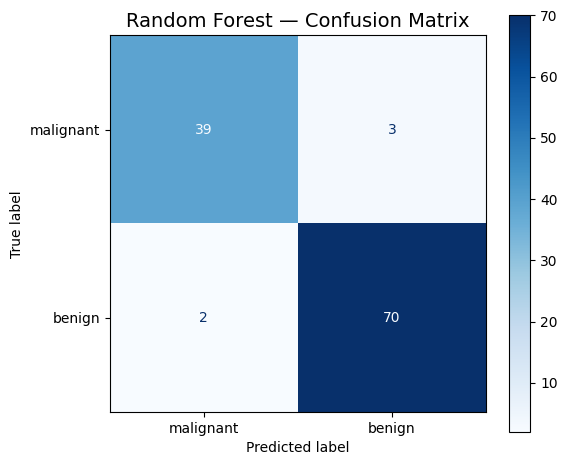

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=data.target_names,
    cmap='Blues', ax=ax
)
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

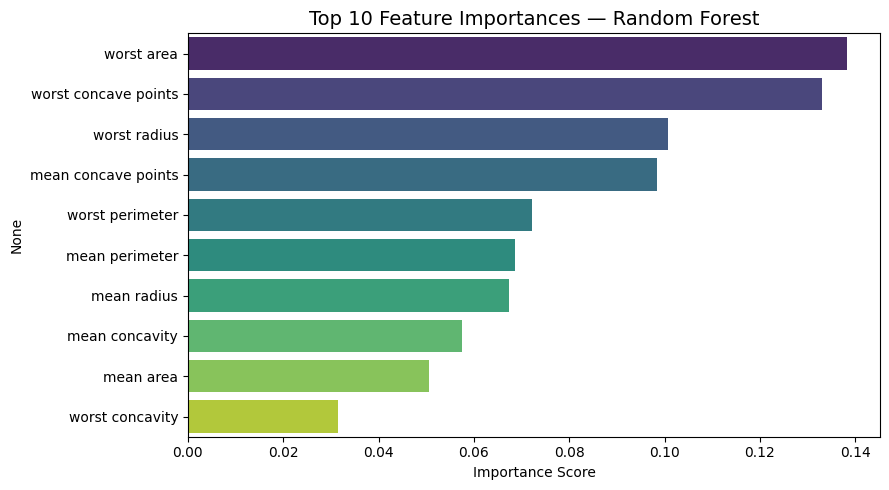

Top 5 Features:
worst area              0.138294
worst concave points    0.132993
worst radius            0.100805
mean concave points     0.098489
worst perimeter         0.072224
dtype: float64


In [7]:
importances = pd.Series(rf.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 Features:')
print(top10.head())

---
## ⚙️ Step 8 — Effect of n_estimators

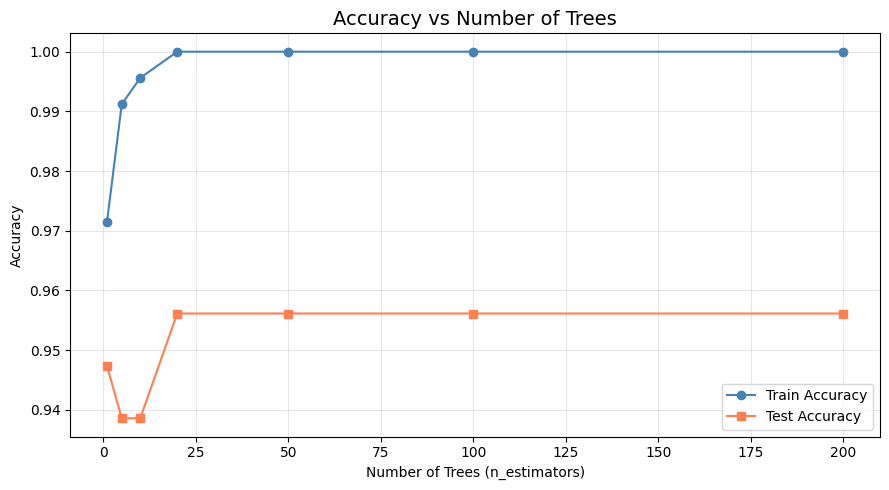

In [8]:
n_trees = [1, 5, 10, 20, 50, 100, 200]
train_scores, test_scores = [], []

for n in n_trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(n_trees, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(n_trees, test_scores,  's-', label='Test Accuracy',  color='coral')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Trees', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔁 Step 9 — Cross Validation

In [9]:
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_final, X, y, cv=5, scoring='accuracy')

print('Cross-Validation Scores (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')

Cross-Validation Scores (5-Fold):
  Fold 1: 0.9211
  Fold 2: 0.9386
  Fold 3: 0.9825
  Fold 4: 0.9649
  Fold 5: 0.9735

Mean  : 0.9561
Std   : 0.0228


---
## ✅ Step 10 — Model Comparison Summary

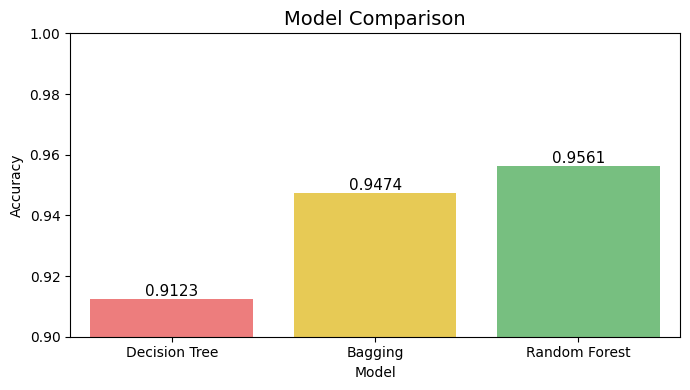

        Model  Test Accuracy
Decision Tree       0.912281
      Bagging       0.947368
Random Forest       0.956140


In [10]:
rf_final.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_final.predict(X_test))

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Random Forest'],
    'Test Accuracy': [dt_acc, bag_acc, rf_acc]
})

plt.figure(figsize=(7, 4))
sns.barplot(data=results, x='Model', y='Test Accuracy', palette=['#ff6b6b','#ffd93d','#6bcb77'])
plt.ylim(0.9, 1.0)
plt.title('Model Comparison', fontsize=14)
plt.ylabel('Accuracy')
for i, row in results.iterrows():
    plt.text(i, row['Test Accuracy'] + 0.001, f"{row['Test Accuracy']:.4f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

---
## 📝 Key Hyperparameters

| Parameter | What it controls | Tip |
|---|---|---|
| `n_estimators` | Number of trees | More = better (but slower) |
| `max_depth` | Max depth per tree | Controls overfitting |
| `max_features` | Features per split | `'sqrt'` for classification |
| `min_samples_split` | Min samples to split node | Higher = more regularization |
| `bootstrap` | Use bootstrap samples | Default True |

---

## 🚀 When to Use Random Forest

✅ Large datasets with many features  
✅ When you need feature importance  
✅ When interpretability is not critical  
✅ As a strong baseline before trying XGBoost  

❌ When you need full interpretability  
❌ Very high-dimensional sparse data (use linear models)  

---
**Next:** `03_Boosting_XGBoost.ipynb` →